In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
from google.colab import drive
drive.mount('/content/drive/')
train_images = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mnist_train.csv')
test_images = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/mnist_test.csv')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [24]:
##Getting the context of the dataset
print("Training images shape:", train_images.shape)
print("Testing images shape:", test_images.shape)

#Column of the dataset
print("Columns of the training images dataset:", train_images.columns)
print("Columns of the testing images dataset:", test_images.columns)

print("Head of the training images dataset:")
train_images.head()


Training images shape: (60000, 785)
Testing images shape: (10000, 785)
Columns of the training images dataset: Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)
Columns of the testing images dataset: Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)
Head of the training images dataset:


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
##Preprocessing the data checking for null values
print("Null values in training images:")
print(train_images.isnull().sum())
print("\nNull values in testing images:")
print(test_images.isnull().sum())

#Using info function to get the data types of the columns in the dataset
print("Info of the training images dataset:")
train_images.info()

Null values in training images:
label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

Null values in testing images:
label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64
Info of the training images dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [26]:
##Using the describe function to get the statistical summary of the dataset
print("Statistical summary of the training images dataset:")
train_images.describe()

Statistical summary of the training images dataset:


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


In [27]:
# Seperate the label column from the training and testing datasets and then start working with the imagegs with the pixel values that shall be normalized between 0 and 1. The label column is the first column of the dataset and the pixel values are the rest of the columns. The pixel values are in the range of 0 to 255. We shall divide the pixel values by 255 to normalize them between 0 and 1.

X_train = train_images.drop('label', axis = 1).values
Y_train = train_images['label'].values

X_test = test_images.drop('label', axis = 1).values
Y_test = test_images['label'].values

#Test the new datasets
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)
print("X_train datatype :", type(X_train))
print("Y_train datatype :", type(Y_train))
print("X_test datatype :", type(X_test))
print("Y_test datatype :", type(Y_test))


(60000, 784) (60000,) (10000, 784) (10000,)
X_train datatype : <class 'numpy.ndarray'>
Y_train datatype : <class 'numpy.ndarray'>
X_test datatype : <class 'numpy.ndarray'>
Y_test datatype : <class 'numpy.ndarray'>


============Train Dataset Statistics ============
Number of samples: 60000
Shape of images: (60000, 784)
Number of classes: 10
Class 0: 5923 samples
Class 1: 6742 samples
Class 2: 5958 samples
Class 3: 6131 samples
Class 4: 5842 samples
Class 5: 5421 samples
Class 6: 5918 samples
Class 7: 6265 samples
Class 8: 5851 samples
Class 9: 5949 samples


/tmp/ipykernel_7280/2188310183.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = np.arange(len(np.bincount(label))), y = np.bincount(label), palette = 'viridis')


============Test Dataset Statistics ============
Number of samples: 10000
Shape of images: (10000, 784)
Number of classes: 10
Class 0: 980 samples
Class 1: 1135 samples
Class 2: 1032 samples
Class 3: 1010 samples
Class 4: 982 samples
Class 5: 892 samples
Class 6: 958 samples
Class 7: 1028 samples
Class 8: 974 samples
Class 9: 1009 samples


/tmp/ipykernel_7280/2188310183.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = np.arange(len(np.bincount(label))), y = np.bincount(label), palette = 'viridis')


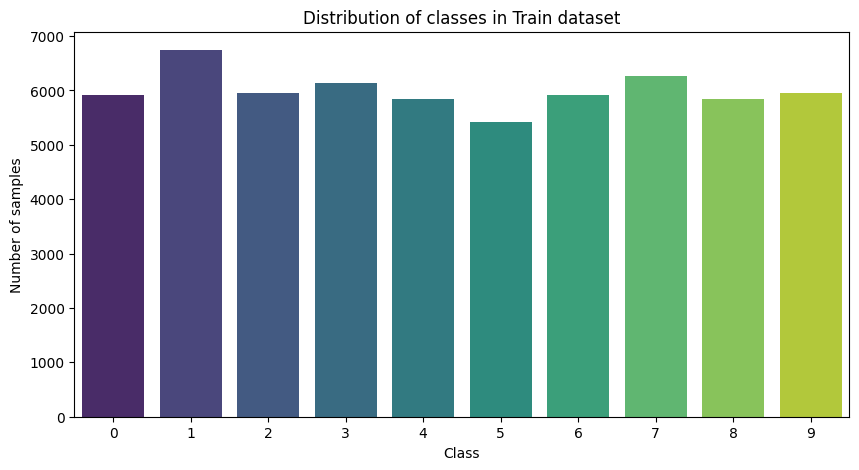

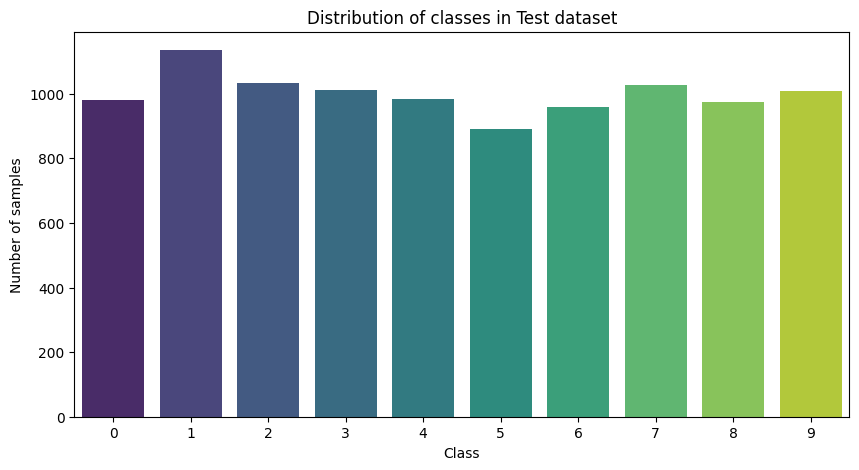

In [28]:
##Normalizing the pixel values of the images between 0 and 1 by dividing the pixel values by 255.0
X_train = X_train / 255.0
X_test = X_test / 255.0

def dataset_statistics(images, label, dataset_name='Train'):
    print(f"============{dataset_name} Dataset Statistics ============")
    print(f"Number of samples: {len(images)}")
    print(f"Shape of images: {images.shape}")
    print(f"Number of classes: {len(np.unique(label))}")

    #Count the number of samples per class
    for i, count in enumerate(np.bincount(label)):
        print(f"Class {i}: {count} samples")

    #Plot the distribution of classes
    plt.figure(figsize = (10, 5))
    sns.barplot(x = np.arange(len(np.bincount(label))), y = np.bincount(label), palette = 'viridis')
    plt.title(f"Distribution of classes in {dataset_name} dataset")
    plt.xlabel("Class")
    plt.ylabel("Number of samples")
    plt.show

dataset_statistics(X_train, Y_train, 'Train')
dataset_statistics(X_test, Y_test, 'Test')

In [29]:
# Reshaping the the training and testing datasets to look like an image inplace of looking like a flattened array for a label The last column is used to indicate the number of chanels which in case of the mnist dataset is 1 since this is a grayscale image. The shape of the training and testing datasets is changed from (60000, 784) to (60000, 28, 28, 1) and (10000, 784) to (10000, 28, 28, 1) respectively.
X_train_img = X_train.reshape(-1, 28, 28, 1)
X_test_img = X_test.reshape(-1, 28, 28, 1)
X_train_img.shape, X_test_img.shape
X_train_img

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [30]:
# Convolutional Neural Networks (CNNs) - The deep learning model which is quite useful for image processing and classification tasks. Althought the CNN model can be used for other tasks as well, it is most commonly used for image classification tasks. The CNN model is composed of several layers which process the images - concolution layers followed by the pooling layers and then the fully connected layers like in ANN.
#The concolution layer are used to extract the features from the images based on filters and kernels. The pooling layers are used to reduce the spatial dimensions of the images and the fully connected layers are used to classify the images based on the features extracted by the concolution layers.

#We are going to use tensor flow to build the CNN model for the MNIST dataset. Tensor flow is an open source deep learning framework which is used to build and train deep learning models

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models

In [31]:
## Building a CNN - A simple 2D convolutional network with two layers of concolution and pooling layer

model_mnist = Sequential(
    [Conv2D(32, kernel_size=(3, 3), activation = 'relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation = 'relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Handling NaN values and One-Hot Encoding Labels

First, I'll replace any `NaN` values in the image data with `0`, as these are likely corrupted or missing pixel values. Then, I'll convert the integer labels into a one-hot encoded format, which is required for training with the `categorical_crossentropy` loss function in Keras.

In [32]:
# Replace NaN values with 0 in the image data
X_train_img = np.nan_to_num(X_train_img, nan=0.0)
X_test_img = np.nan_to_num(X_test_img, nan=0.0)

# One-hot encode the labels
Y_train_encoded = to_categorical(Y_train, num_classes=10)
Y_test_encoded = to_categorical(Y_test, num_classes=10)

print("Shape of X_train_img after NaN handling:", X_train_img.shape)
print("Shape of Y_train_encoded:", Y_train_encoded.shape)
print("Shape of X_test_img after NaN handling:", X_test_img.shape)
print("Shape of Y_test_encoded:", Y_test_encoded.shape)

Shape of X_train_img after NaN handling: (60000, 28, 28, 1)
Shape of Y_train_encoded: (60000, 10)
Shape of X_test_img after NaN handling: (10000, 28, 28, 1)
Shape of Y_test_encoded: (10000, 10)


### Compiling and Training the CNN Model

Now, I'll compile the `model_mnist` using the Adam optimizer, `categorical_crossentropy` loss, and 'accuracy' as a metric. I will then train the model using a validation split to monitor performance during training and observe for overfitting or underfitting.

In [33]:
# Compile the model
model_mnist.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model_mnist.fit(
    X_train_img, Y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 35ms/step - accuracy: 0.9219 - loss: 0.2559 - val_accuracy: 0.9805 - val_loss: 0.0661
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 34ms/step - accuracy: 0.9727 - loss: 0.0924 - val_accuracy: 0.9869 - val_loss: 0.0461
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.9798 - loss: 0.0677 - val_accuracy: 0.9889 - val_loss: 0.0404
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.9828 - loss: 0.0554 - val_accuracy: 0.9907 - val_loss: 0.0353
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9868 - loss: 0.0437 - val_accuracy: 0.9864 - val_loss: 0.0486
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9883 - loss: 0.0372 - val_accuracy: 0.9907 - val_loss: 0.0344
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9900 - loss: 0.0323 - val_accuracy: 0.9902 - val_loss: 0.0374
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 34ms/step - accuracy: 0.9908 -

### Visualizing Training and Validation Metrics

To assess the model's performance and detect any signs of overfitting or underfitting, I'll plot the training and validation loss, as well as the training and validation accuracy over the epochs.

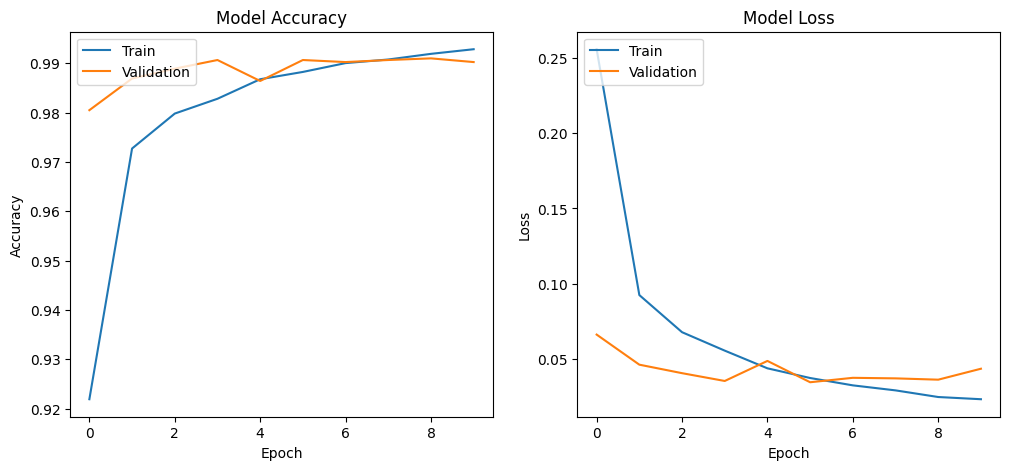

In [34]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

### Evaluating the Model on the Test Dataset

Finally, I'll evaluate the trained model on the unseen test dataset to get a final measure of its generalization performance.

In [35]:
# Evaluate the model on the test data
loss, accuracy = model_mnist.evaluate(X_test_img, Y_test_encoded, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0296
Test Accuracy: 0.9916


In [ ]:
# Model Evaluation on the basis of Confusion matrix, F1 score, Accuracy, Precision, Recall



313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000


Confusion Matrix:


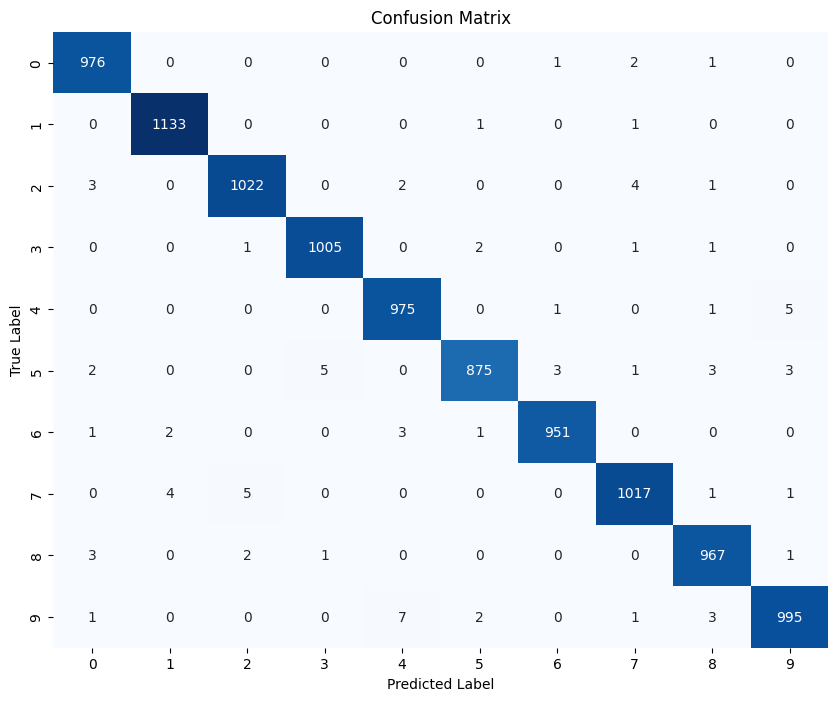

In [36]:
#To thoroughly evaluate the trained CNN model, I will compute and display various classification metrics. This includes:

#Accuracy: The proportion of correctly classified instances.
#Precision: The ability of the classifier not to label as positive a sample that is negative.
#Recall: The ability of the classifier to find all the positive samples.
#F1-Score: The harmonic mean of precision and recall, providing a balanced measure.
#Confusion Matrix: A table that describes the performance of a classification model on a set of test data for which the true values are known. It allows for visualization of the performance of an algorithm

# Predict the classes for the test set
Y_pred_probs = model_mnist.predict(X_test_img)
Y_pred_classes = np.argmax(Y_pred_probs, axis=1)

# Get true classes (if Y_test_encoded was used, convert back, otherwise use Y_test directly)
# Assuming Y_test is the original integer labels
Y_true_classes = Y_test

# Generate classification report
print("\nClassification Report:")
print(classification_report(Y_true_classes, Y_pred_classes))

# Generate confusion matrix
conf_matrix = confusion_matrix(Y_true_classes, Y_pred_classes)

print("\nConfusion Matrix:")
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

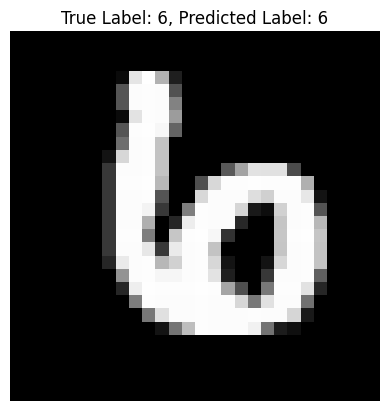

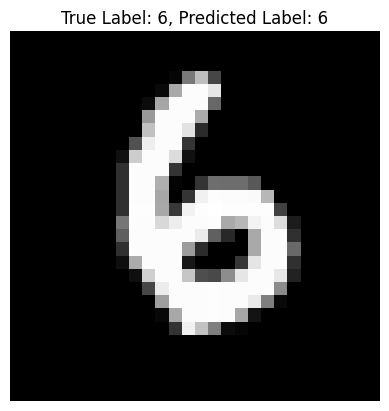

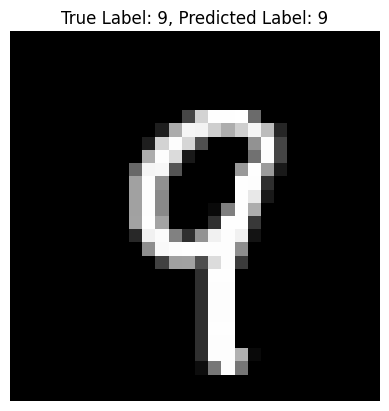

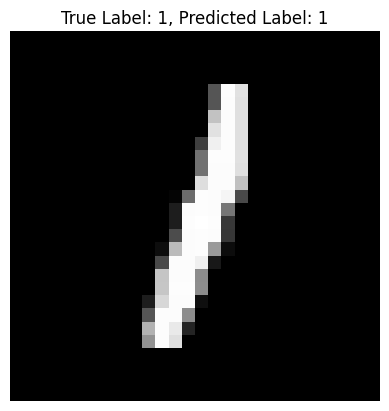

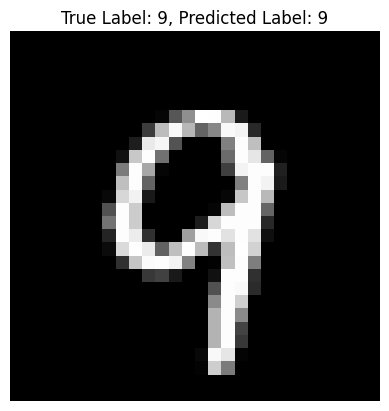

In [37]:
# Manual Validation of the images
for i in range(5):  # Display 5 random test images
    idx = np.random.randint(0, X_test_img.shape[0])
    img = X_test_img[idx].reshape(28,28)  # Reshape to 28x28 for display
    true_label = Y_test[idx]
    pred_label = Y_pred_classes[idx]
    plt.imshow(img, cmap='gray')
    plt.title(f"True Label: {true_label}, Predicted Label: {pred_label}")
    plt.axis('off')
    plt.show()